# **Part 1: Visualization & Exploratory Data Analysis (EDA)**

### **Dataset Introduction**

In this project, we will work with the Palmer Penguins dataset, which contains measurements of penguins observed on islands near Antarctica.

Please download the dataset [penguins.csv](https://drive.google.com/file/d/1dv8A8v_sdf29p1At40S7KBslJPmBA3e9/view?usp=sharing) or from canvas.

### **Dataset Description**

Each row represents a penguin, and columns include:

- species – Penguin species
- island – Island where the penguin was found
- bill_length_mm – Bill length (mm)
- bill_depth_mm – Bill depth (mm)
- flipper_length_mm – Flipper length (mm)
- body_mass_g – Body mass (grams)
- sex – Sex of the penguin

Some values are missing, which makes this dataset ideal for practicing missing data handling.



Your task is to perform a comprehensive Exploratory Data Analysis (EDA) and visualization on the Palmer Penguins dataset. This project aims to deepen your understanding of data characteristics, relationships between variables, and effective data presentation using Python's data science libraries.

**Instructions:**

1.  **Load the Dataset:** Begin by loading the `penguins.csv` dataset into a pandas DataFrame.
2.  **Initial Data Inspection:** Perform an initial inspection to understand the dataset's structure. Display the first few rows, check data types and non-null values, and generate descriptive statistics.
3.  **Handle Missing Values:** Identify and address any missing values in the dataset. Clearly explain your chosen strategy for handling missing data (e.g., imputation, dropping rows/columns) and justify your decision.
4.  **Perform EDA and Visualization:** Conduct a thorough EDA, exploring distributions, relationships, and patterns within the data. You are required to use **at least three distinct types of visualizations** (e.g., histograms, scatter plots, box plots, bar charts). For each visualization:
    *   Justify your choice of plot type, explaining why it is suitable for the variables being analyzed.
    *   Clearly articulate what insights each visualization reveals about the data (e.g., distributions, correlations, outliers, group differences).
5.  **Summarize Key Findings:** Based on your EDA and visualizations, summarize the most important insights and observations about the Palmer Penguins dataset. Highlight any discovered patterns, trends, anomalies, or interesting relationships.
6.  **Final Task:** Present your complete EDA and visualization analysis, emphasizing key takeaways and interpretations of the observed data characteristics and relationships in a clear and concise manner.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [10]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [11]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


The dataset contains some missing values. I chose to remove rows containing missing values because the dataset has many observations and only a relatively small number of rows are incomplete. This allows the analysis to use complete observations without estimating or inventing values.

In [12]:
df_clean = df.dropna()
df_clean.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


I chose a histogram because it is useful for showing the distribution of a numerical variable. This graph allows us to see how penguin body masses are distributed and identify common ranges or unusual values.

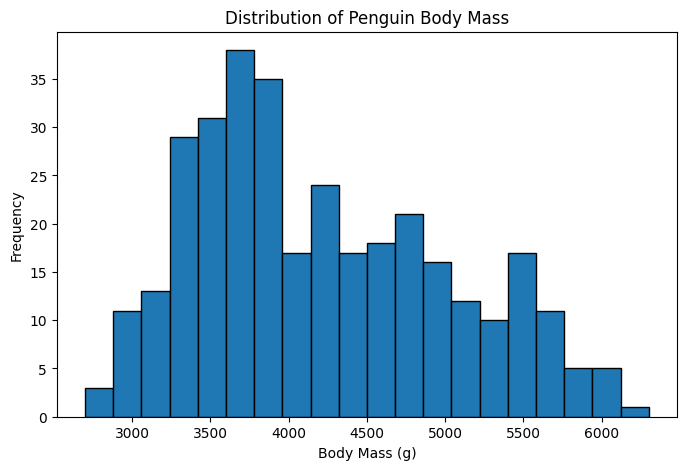

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['body_mass_g'], bins=20, edgecolor='black')
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.title('Distribution of Penguin Body Mass')
plt.show()

The histogram shows that penguin body mass varies considerably throughout the dataset. Most penguins fall within the middle ranges, while fewer penguins have extremely low or high body masses. This suggests that there are noticeable differences in body size among the penguins.

I chose a scatter plot because both flipper length and body mass are numerical variables. A scatter plot makes it easy to examine whether there is a relationship between two quantitative measurements.

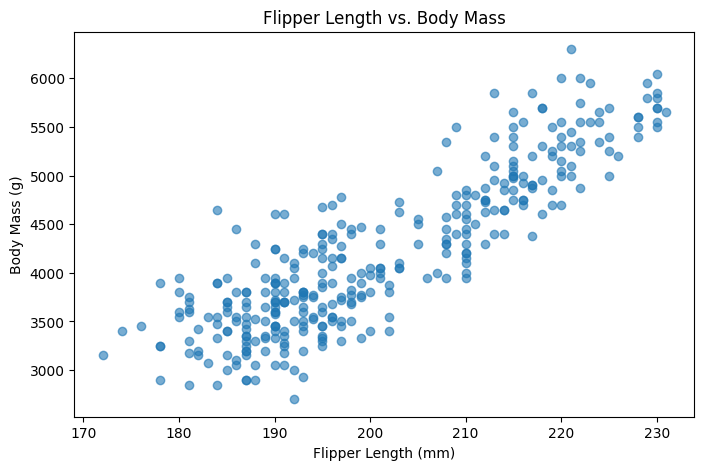

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['flipper_length_mm'], df_clean['body_mass_g'], alpha=0.6)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Flipper Length vs. Body Mass')
plt.show()

The scatter plot shows a positive relationship between flipper length and body mass. In general, penguins with longer flippers tend to have greater body mass. The points also appear to form groups, which may be related to differences among penguin species.

I chose a box plot because it makes it easy to compare the distribution of a numerical variable across different categories. Here, it allows us to compare body mass among the different penguin species.

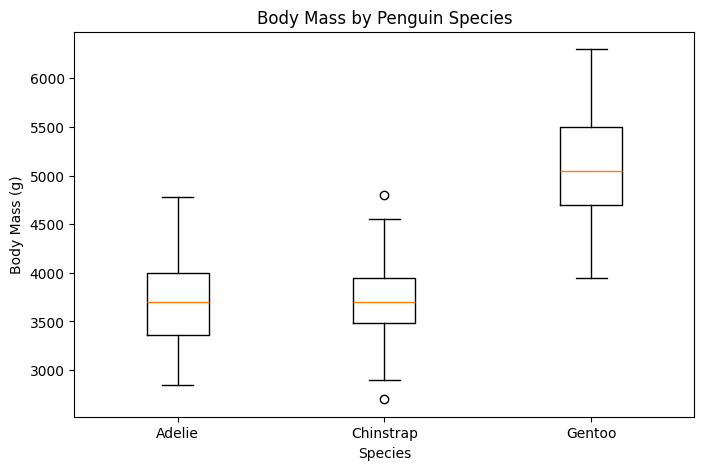

In [15]:
species = df_clean['species'].unique()

data = [
    df_clean[df_clean['species'] == s]['body_mass_g']
    for s in species
]

plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=species)
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.title('Body Mass by Penguin Species')
plt.show()

The box plot shows clear differences in body mass among the penguin species. Gentoo penguins generally have a higher body mass than Adelie and Chinstrap penguins. This suggests that species is strongly associated with differences in penguin body size.

I chose a bar chart because species is a categorical variable. A bar chart clearly shows the number of observations belonging to each species.

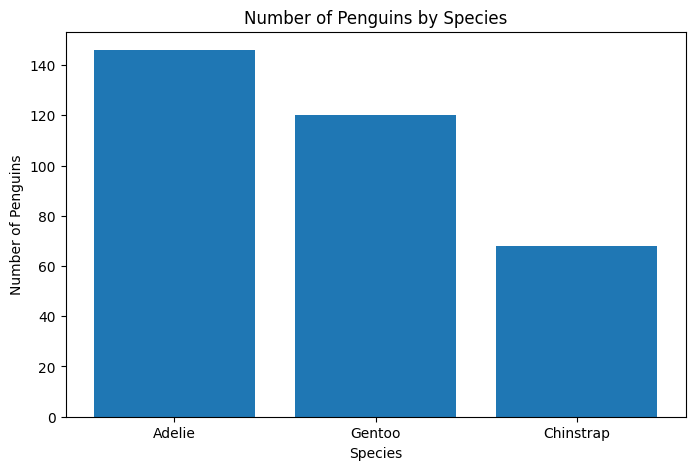

In [16]:
species_counts = df_clean['species'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(species_counts.index, species_counts.values)
plt.xlabel('Species')
plt.ylabel('Number of Penguins')
plt.title('Number of Penguins by Species')
plt.show()

The bar chart shows that the species are not represented equally in the dataset. Adelie penguins have the largest number of observations, while Chinstrap penguins have the fewest.

In [17]:
df_clean.groupby('species')[['bill_length_mm', 'bill_depth_mm',
                             'flipper_length_mm', 'body_mass_g']].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.542500,15.002500,217.233333,5090.625000


The exploratory data analysis revealed several important patterns in the Palmer Penguins dataset. Penguin measurements differ noticeably among species. Gentoo penguins generally have greater body mass and longer flippers than the other species. Flipper length and body mass also show a positive relationship, meaning that penguins with longer flippers tend to weigh more. The distribution of observations across species is uneven, with Adelie having the most observations and Chinstrap having the fewest. Overall, species appears to be an important factor associated with differences in the physical characteristics of the penguins.

This analysis used data inspection, missing-value handling, descriptive statistics, and multiple visualizations to explore the Palmer Penguins dataset. Histograms, scatter plots, box plots, and bar charts revealed differences in distributions, relationships between numerical measurements, and differences among species. Removing the relatively small number of incomplete observations allowed the analysis to focus on complete data. Overall, the results demonstrate clear relationships between species, body mass, flipper length, and other physical measurements.